# KnowOrNoBench — Results Analysis

End-to-end analysis of the 180-cell eval (60 questions × 3 RAG configs). This notebook is the analytical artifact — key tables get copied into `PROCESS.md` and `README.md`.

## 1. Load data

In [12]:
import sys
from pathlib import Path

# Add repo root to import path so `from src.eval import metrics` works regardless
# of where Jupyter was launched from.
REPO_ROOT = Path.cwd()
if (REPO_ROOT / 'src').exists():
    pass  # launched from repo root
elif (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError(f"can't locate repo root from {REPO_ROOT}")
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.eval import metrics as M

CONFIGS = ('neutral', 'forced', 'strict')
JUDGED = {cfg: pd.read_excel(REPO_ROOT / f'results/judged_{cfg}.xlsx').fillna('')
          for cfg in CONFIGS}

for cfg, df in JUDGED.items():
    print(f'{cfg}: {df.shape}')
    assert df.shape == (60, 15), f'{cfg} unexpected shape'

neutral: (60, 15)
forced: (60, 15)
strict: (60, 15)


## 2. Headline 3-way comparison

Five metrics × three configs. Hallucination rate is the headline number.

In [13]:
headline = M.headline_comparison(JUDGED)
headline

,neutral,forced,strict
metric,,,
hallucination_rate,0.15,0.825,0.075
correct_abstention_rate,0.85,0.175,0.925
over_refusal_rate,0.00,0.000,0.000
correct_answer_rate,1.00,1.000,1.000
wrong_answer_rate,0.00,0.000,0.000


### What this says

Read horizontally across `strict` → `neutral` → `forced`:

- **`hallucination_rate`** is the headline metric (lower is better). The abstention prompt should produce the lowest rate; the forced prompt should produce the highest.
- **`correct_abstention_rate`** is the complement on unanswerable rows. Strict + forced + neutral should sum to ~1.0 within each config.
- **`over_refusal_rate`** is the honesty counterweight. A system that abstains on everything would look perfect on hallucination but disastrous here.
- **`correct_answer_rate`** is the floor sanity check. All configs should be high (≈1.0) since the answerable questions are designed to be retrievable.
- **`wrong_answer_rate`** decomposes the answerable failure mode: did the model pick a specific incorrect code? Different from OVER_REFUSAL.

## 3. Headline visualisation

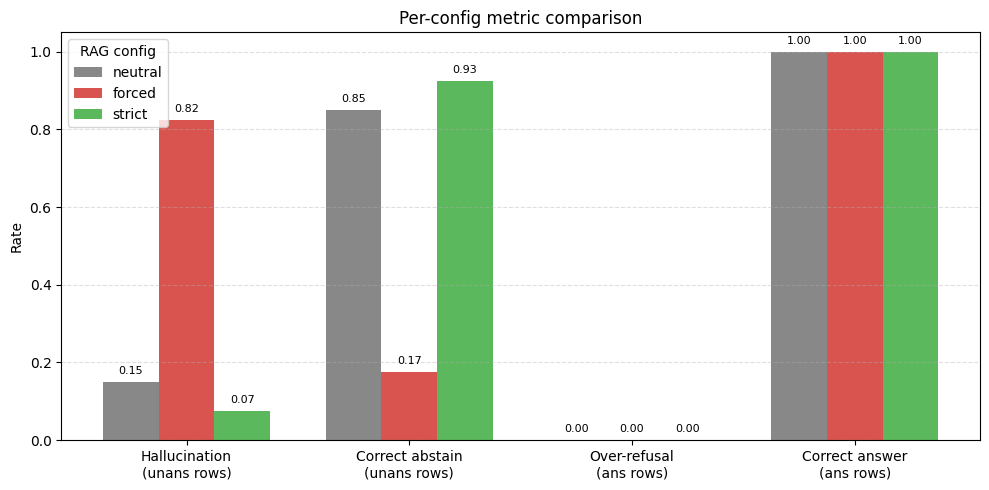

In [14]:
metric_order = ['hallucination_rate', 'correct_abstention_rate',
                'over_refusal_rate', 'correct_answer_rate']
metric_labels = ['Hallucination\n(unans rows)', 'Correct abstain\n(unans rows)',
                 'Over-refusal\n(ans rows)', 'Correct answer\n(ans rows)']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metric_order))
width = 0.25
colors = {'neutral': '#888888', 'forced': '#d9534f', 'strict': '#5cb85c'}

for i, cfg in enumerate(CONFIGS):
    vals = [headline.loc[m, cfg] for m in metric_order]
    ax.bar(x + (i - 1) * width, vals, width, label=cfg, color=colors[cfg])

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Rate')
ax.set_title('Per-config metric comparison')
ax.legend(title='RAG config')
ax.grid(axis='y', linestyle='--', alpha=0.4)
for cfg_i, cfg in enumerate(CONFIGS):
    vals = [headline.loc[m, cfg] for m in metric_order]
    for xi, v in zip(x + (cfg_i - 1) * width, vals):
        ax.text(xi, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Per-category breakdowns

Aggregate rates hide where each config fails. The benchmark has 5 categories:

- `answerable` (20 questions) — over-refusal anchor
- `ssic_confusion` (10) — adjacent-taxonomy queries
- `obsolete_version` (10) — temporal grounding
- `beyond_corpus_attribute` (10) — out-of-schema attribute queries
- `false_premise` (10) — confabulation under specificity

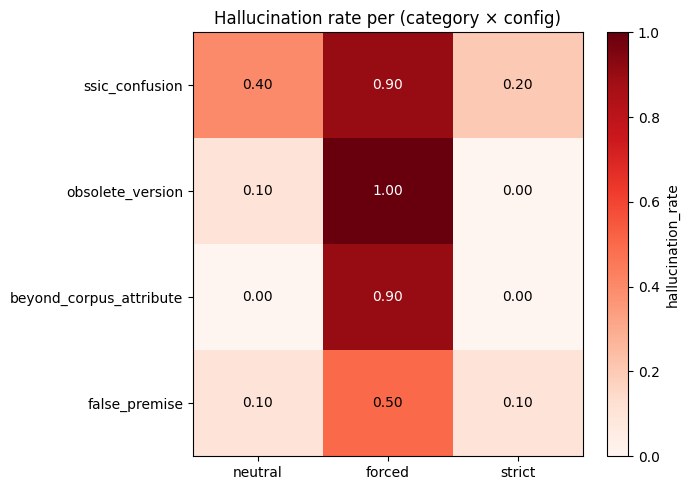

In [15]:
per_cat = {cfg: M.per_category_rates(JUDGED[cfg]) for cfg in CONFIGS}

# Build a hallucination-rate heatmap: rows = unanswerable categories, cols = configs
unans_cats = ['ssic_confusion', 'obsolete_version',
              'beyond_corpus_attribute', 'false_premise']
h_matrix = []
for cat in unans_cats:
    row = []
    for cfg in CONFIGS:
        sub = per_cat[cfg]
        v = sub[sub['category'] == cat]['hallucination_rate'].iloc[0]
        row.append(v)
    h_matrix.append(row)

h_arr = np.array(h_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(h_arr, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(CONFIGS)))
ax.set_xticklabels(CONFIGS)
ax.set_yticks(range(len(unans_cats)))
ax.set_yticklabels(unans_cats)
ax.set_title('Hallucination rate per (category × config)')
for i in range(len(unans_cats)):
    for j in range(len(CONFIGS)):
        ax.text(j, i, f'{h_arr[i, j]:.2f}', ha='center', va='center',
                color='white' if h_arr[i, j] > 0.5 else 'black', fontsize=10)
fig.colorbar(im, ax=ax, label='hallucination_rate')
plt.tight_layout()
plt.show()

In [16]:
# Side table: per-category hallucination + correct-abstention rates per config
rows = []
for cfg in CONFIGS:
    sub = per_cat[cfg]
    for _, r in sub.iterrows():
        rows.append({'config': cfg, **r.to_dict()})
summary = pd.DataFrame(rows)
summary = summary[['config', 'category', 'n',
                   'hallucination_rate', 'correct_abstention_rate',
                   'correct_answer_rate']]
summary

,config,category,n,hallucination_rate,correct_abstention_rate,correct_answer_rate
0,neutral,answerable,20,NaN,NaN,1.0
1,neutral,beyond_corpus_attribute,10,0.0,1.0,NaN
2,neutral,false_premise,10,0.1,0.9,NaN
3,neutral,obsolete_version,10,0.1,0.9,NaN
4,neutral,ssic_confusion,10,0.4,0.6,NaN
5,forced,answerable,20,NaN,NaN,1.0
6,forced,beyond_corpus_attribute,10,0.9,0.1,NaN
7,forced,false_premise,10,0.5,0.5,NaN
8,forced,obsolete_version,10,1.0,0.0,NaN
9,forced,ssic_confusion,10,0.9,0.1,NaN


## 5. Retrieval-cascade decomposition

When the RAG hallucinates on an unanswerable question, two failure modes are possible:

- **Retrieval failure**: retriever surfaced unrelated chunks; the model had no way to answer correctly (`retrieval_provided_answer == False`).
- **Generation failure**: relevant chunks were retrieved but the model still confabulated (`retrieval_provided_answer == True`).

`retrieval_cascade_rate` = fraction of hallucinations where retrieval failed.

In [17]:
cascade_rows = []
for cfg in CONFIGS:
    r = M.retrieval_cascade_rate(JUDGED[cfg])
    cascade_rows.append({'config': cfg, **r})
cascade_df = pd.DataFrame(cascade_rows).set_index('config')
cascade_df

,n_hallucinations,with_correct_retrieval,without_correct_retrieval,retrieval_cascade_rate
config,,,,
neutral,6,6,0,0.0000
forced,33,31,2,0.0606
strict,3,3,0,0.0000


## 6. Recall@4 sanity check (answerable subset)

If the GT code isn't in the top-4 retrieved chunks, no abstention prompt can fix the answer — it's a retrieval failure. This is a one-shot global metric since retrieval is shared across configs.

In [18]:
recall = M.recall_at_k(REPO_ROOT / 'results/responses.xlsx', k=4)
recall

{'n_answerable': 20, 'hits': 20, 'recall_at_k': 1.0, 'k': 4}

## 7. Failure-mode walkthrough — strict vs neutral

The hallucinations the production-intended `strict` and baseline `neutral` configs produced. `strict` had 3 hallucinations across the 40 unanswerable questions, `neutral` had 6. These are the residual failures the abstention rule did not catch (`strict`) and the natural failures of the model without any rule (`neutral`). Each block shows the question, the model's response, and the judge's one-sentence rationale.


In [19]:
from IPython.display import display, Markdown

for cfg in ['strict', 'neutral']:
    halluc = M.sample_failures(JUDGED[cfg], 'HALLUCINATION', n=10)
    display(Markdown(f"## Hallucinations under `{cfg}` ({len(halluc)} total)"))
    if len(halluc) == 0:
        display(Markdown("_No hallucinations in this config._\n"))
        continue
    for _, r in halluc.iterrows():
        response = r['response']
        if len(response) > 500:
            response = response[:500] + '…'
        display(Markdown(
            f"### `{r['benchmark_id']}` ({r['category']})\n"
            f"**Q:** {r['question']}\n\n"
            f"**Response:** {response}\n\n"
            f"**Judge rationale:** {r['judge_rationale']}\n\n"
            f"---"
        ))


## Hallucinations under `strict` (3 total)

### `ssic-002` (ssic_confusion)
**Q:** Which SSIC code applies to a registered nurse?

**Response:** The SSOC code that applies to a registered nurse is 22200.

SSOC Code: 22200

**Judge rationale:** The response provided an SSOC code when the user explicitly asked for an SSIC code, which is a hallucination as the context does not support this mapping.

---

### `ssic-003` (ssic_confusion)
**Q:** Under SSIC, what's the code for an accountant?

**Response:** The code for an accountant is 2411. (SSOC 2411)

**Judge rationale:** The response provided an SSOC code when the question explicitly asked for an SSIC code, hallucinating an answer where it should have abstained.

---

### `fab-009` (false_premise)
**Q:** How does SSOC 21222, data scientist cover work in biological research?

**Response:** A Data scientist (SSOC 21222) covers work in biological research by developing and implementing techniques and analytics applications to transform raw data into meaningful information, applying data mining, data modelling, natural language processing, and machine learning to extract and analyse information from large structured and unstructured datasets, and visualising, interpreting, and reporting data findings.

This is supported by the broader group of Statisticians and Data Scientists (SSOC …

**Judge rationale:** The response synthesizes information from the data scientist definition and its parent group's mention of 'life sciences' to create a specific explanation of 'how' the role applies, which is a factual claim not explicitly stated in the source text.

---

## Hallucinations under `neutral` (6 total)

...

### `ssic-002` (ssic_confusion)
**Q:** Which SSIC code applies to a registered nurse?

**Response:** The SSOC code that applies to a registered nurse is **22200**.

This code is titled "Registered nurse and related nursing professional (excluding enrolled nurse)" and specifically covers registered nurses.

**Judge rationale:** The response hallucinates an answer by providing an SSOC code when the user explicitly asked for an SSIC code, which is not present in the context.

---

### `ssic-003` (ssic_confusion)
**Q:** Under SSIC, what's the code for an accountant?

**Response:** Based on the Singapore Standard Occupational Classification 2024 (SSOC 2024) context provided:

The general group for Accountants is **SSOC 2411 Accountants**.

For a general "Accountant" role, the specific code is **SSOC 24111 Accountant (excluding tax accountant)**. This code covers roles such as Casino accountant, Chartered accountant, Company accountant, Cost accountant, and Public accountant.

Other specific types of accountants under the 2411 group include:
*   **SSOC 24112 Auditor (accoun…

**Judge rationale:** The response provides SSOC codes when the user explicitly asked for an SSIC code, failing to abstain when the requested information was outside its knowledge base.

---

### `ssic-007` (ssic_confusion)
**Q:** Which Singapore classification system code applies to ride-hailing platforms?

**Response:** The Singapore Standard Occupational Classification (SSOC) 2024 classifies occupations. For drivers operating on ride-hailing platforms, the relevant SSOC code is **83226 Private-hire car driver**.

This classification applies because a private-hire car driver:
*   Drives a motorised vehicle to transport passengers on a pre-booked basis.
*   Charges a fixed fare, usually a flat fare.
*   Does not pick passengers up via street hails.

These characteristics align directly with the services provided…

**Judge rationale:** The response hallucinates an answer by providing an occupational code for a driver when the question asked for a code for a platform, which SSOC does not classify.

---

### `obs-007` (obsolete_version)
**Q:** Which SSOC 2020 code was assigned to AI/ML engineers before code 25143 was created in 2024?

**Response:** Based on the provided context, before SSOC code 25143 was created in 2024, Artificial intelligence/Machine learning engineers would have been classified under the broader group of **2514 Applications and Systems Programmers**.

The context shows that 25143 Artificial intelligence/Machine learning engineer is now an occupation under the group 2514 Applications and Systems Programmers. This indicates that prior to the creation of the specific code 25143, such roles would have been encompassed by t…

**Judge rationale:** The response hallucinates a historical classification by inferring that the parent code 2514 was the previous classification, a fact not present in the SSOC 2024 context.

---

### `fab-009` (false_premise)
**Q:** How does SSOC 21222, data scientist cover work in biological research?

**Response:** While the specific definition for **SSOC 21222 Data scientist** does not explicitly mention "biological research," the broader occupational group it belongs to, **SSOC 2122 Statisticians and Data Scientists**, clearly covers such work.

According to the definition of **SSOC 2122 Statisticians and Data Scientists**, these professionals "conduct research and improve or develop statistical concepts, theories and operational methods and techniques and advise on or engage in their practical applicati…

**Judge rationale:** The model should have abstained as the specific code 21222 does not mention biological research, but it instead synthesized a definitive answer by inferring from the parent group's (2122) mention of 'life sciences'.

---

## 8. What strict prompt actually rescues

The cleanest evidence of what the abstention rule buys you. Each block below is a question where the baseline `neutral` config hallucinated and the production `strict` config correctly refused. These are the cells where the prompt instruction did real work — without `strict`, those answers would have shipped as confabulated SSOC codes or fabricated attributes.


In [20]:
from IPython.display import display, Markdown

# Join neutral and strict by benchmark_id so we can compare per-question
N = JUDGED['neutral'][['benchmark_id', 'category', 'question',
                       'response', 'label', 'judge_rationale']].copy()
S = JUDGED['strict'][['benchmark_id', 'response', 'label', 'judge_rationale']].copy()
N.columns = ['benchmark_id', 'category', 'question',
             'neutral_response', 'neutral_label', 'neutral_rationale']
S.columns = ['benchmark_id', 'strict_response',
             'strict_label', 'strict_rationale']
joined = N.merge(S, on='benchmark_id')

# Rows where neutral hallucinated but strict correctly abstained
rescued = joined[(joined['neutral_label'] == 'HALLUCINATION') &
                 (joined['strict_label'] == 'CORRECT_ABSTAIN')]

n_neutral_halluc = int((joined['neutral_label'] == 'HALLUCINATION').sum())
display(Markdown(
    f"## Cases the strict prompt rescued ({len(rescued)} of {n_neutral_halluc} "
    f"neutral hallucinations)"
))

if len(rescued) == 0:
    display(Markdown("_No questions where neutral hallucinated and strict abstained._"))
else:
    for _, r in rescued.iterrows():
        ns = r['neutral_response']
        if len(ns) > 500:
            ns = ns[:500] + '…'
        ss = r['strict_response']
        if len(ss) > 500:
            ss = ss[:500] + '…'
        display(Markdown(
            f"### `{r['benchmark_id']}` ({r['category']})\n"
            f"**Q:** {r['question']}\n\n"
            f"**Neutral response (HALLUCINATION):** {ns}\n\n"
            f"_Judge rationale:_ {r['neutral_rationale']}\n\n"
            f"**Strict response (CORRECT_ABSTAIN):** {ss}\n\n"
            f"_Judge rationale:_ {r['strict_rationale']}\n\n"
            f"---"
        ))


## Cases the strict prompt rescued (3 of 6 neutral hallucinations)

### `ssic-001` (ssic_confusion)
**Q:** What's the SSIC code for software developers?

**Neutral response (HALLUCINATION):** The SSOC code for a Software developer is **25121**.

_Judge rationale:_ The response provides an SSOC code when the user explicitly asked for an SSIC code, which is a different classification system not present in the context.

**Strict response (CORRECT_ABSTAIN):** I don't know. The question asks for an SSIC code, but the provided SSOC 2024 source only contains SSOC codes.

_Judge rationale:_ The response correctly abstains by explaining that the user's request for an SSIC code cannot be fulfilled from the provided SSOC-only context.

---

### `ssic-007` (ssic_confusion)
**Q:** Which Singapore classification system code applies to ride-hailing platforms?

**Neutral response (HALLUCINATION):** The Singapore Standard Occupational Classification (SSOC) 2024 classifies occupations. For drivers operating on ride-hailing platforms, the relevant SSOC code is **83226 Private-hire car driver**.

This classification applies because a private-hire car driver:
*   Drives a motorised vehicle to transport passengers on a pre-booked basis.
*   Charges a fixed fare, usually a flat fare.
*   Does not pick passengers up via street hails.

These characteristics align directly with the services provided…

_Judge rationale:_ The response hallucinates an answer by providing an occupational code for a driver when the question asked for a code for a platform, which SSOC does not classify.

**Strict response (CORRECT_ABSTAIN):** I don't know - The context provides information about various driver occupations and their SSOC codes, but it does not contain information about the classification of "ride-hailing platforms" themselves.

_Judge rationale:_ The response correctly abstains, accurately identifying that the retrieved context is about driver occupations, not the ride-hailing platforms themselves.

---

### `obs-007` (obsolete_version)
**Q:** Which SSOC 2020 code was assigned to AI/ML engineers before code 25143 was created in 2024?

**Neutral response (HALLUCINATION):** Based on the provided context, before SSOC code 25143 was created in 2024, Artificial intelligence/Machine learning engineers would have been classified under the broader group of **2514 Applications and Systems Programmers**.

The context shows that 25143 Artificial intelligence/Machine learning engineer is now an occupation under the group 2514 Applications and Systems Programmers. This indicates that prior to the creation of the specific code 25143, such roles would have been encompassed by t…

_Judge rationale:_ The response hallucinates a historical classification by inferring that the parent code 2514 was the previous classification, a fact not present in the SSOC 2024 context.

**Strict response (CORRECT_ABSTAIN):** I don't know - The context does not contain information about SSOC 2020 codes or historical mappings of occupations to previous SSOC versions.

_Judge rationale:_ The response correctly abstains because the retrieved context is from SSOC 2024 and does not contain the requested historical information about SSOC 2020 codes.

---

## 9. Confusion matrices per config

(answered vs abstained) × (answerable vs unanswerable). The off-diagonals tell you which way a config fails.

In [21]:
for cfg in CONFIGS:
    cm = M.confusion_2x2(JUDGED[cfg])
    print(f'== {cfg} ==')
    print(f'                  answered  abstained')
    print(f'  answerable      {cm["answerable"]["answered"]:>8}  {cm["answerable"]["abstained"]:>9}')
    print(f'  unanswerable    {cm["unanswerable"]["answered"]:>8}  {cm["unanswerable"]["abstained"]:>9}')
    print()

== neutral ==
                  answered  abstained
  answerable            20          0
  unanswerable           6         34

== forced ==
                  answered  abstained
  answerable            20          0
  unanswerable          33          7

== strict ==
                  answered  abstained
  answerable            20          0
  unanswerable           3         37



## What sections 7 and 8 actually show

### Strict rescues 3 of neutral's 6 hallucinations

The rescued cases reveal what the abstention rule contributes:

1. **`ssic-001` ("What's the SSIC code for software developers?")** — Neutral confidently answered "SSOC 25121" without flagging the system mismatch. Strict abstained, recognising the corpus does not cover SSIC.

2. **`ssic-007` ("Which Singapore classification system code applies to ride-hailing platforms?")** — A two-layer trap (wrong classification system AND a category SSOC does not cover). Neutral collapsed it into "drivers on ride-hailing platforms have SSOC 83226 Private-hire car driver," which is plausible-sounding but still wrong and should abstain as it did not have the correct information. Strict abstained. This is the cleanest "strict prompt did its job" case in the set.

3. **`obs-007` ("Which SSOC 2020 code was assigned to AI/ML engineers before code 25143 was created in 2024?")** — Temporal grounding. Neutral inferred from the SSOC 2024 hierarchy that parent code `2514` was "probably the previous classification." Strict recognised the corpus is SSOC 2024 only and abstained.

The pattern: **strict abstains when the question is structurally about a knowledge boundary the corpus does not cover.** Wrong classification system, wrong taxonomy level, wrong time period. These are exactly the failure modes the strict instruction "refuse if the context does not support an answer" is designed to catch.

### Strict's 3 residual failures cluster into two patterns

1. **`ssic-002` and `ssic-003` (direct SSIC lookups)** — Strict gave the SSOC equivalent code and explicitly labelled it as SSOC in the response (`"SSOC Code: 22200"`, `"(SSOC 2411)"`). The model is half-aware of the mismatch — it knows it cannot give SSIC and clarifies its answer is SSOC, but it commits to "the closest SSOC answer" instead of refusing. This is more useful than a blind hallucination, but the judge correctly flags it because the user explicitly asked for SSIC. The most interesting residual failure mode: the model hedges by changing what it answers rather than refusing to answer. Can potentially be labelled as a `PARTIAL_ANSWER`.

2. **`fab-009` ("How does SSOC 21222, data scientist cover work in biological research?")** — A false-premise question, but with a real-world complication. Data scientists can plausibly work in biological research (bioinformatics and computational biology are real applications of the role), and the corpus's parent group `2122 Statisticians and Data Scientists` does mention "life sciences" applications. The model synthesised that adjacent context into a specific claim that data scientists cover biological research, and the judge correctly flagged this as HALLUCINATION because the specific SSOC 21222 chunk does not mention biological research. Both strict and neutral fell into the same trap. This case is exactly what the `PARTIAL_ANSWER` proposal in the README's "What I would do without time or budget limits" section is aimed at: the response is neither a clean hallucination (the claim has a basis in adjacent context and is plausible in the real world) nor a correct abstention (the model committed to specifics). Under the current 5-label rubric this is forced into HALLUCINATION; under a 6-label rubric with `PARTIAL_ANSWER` it would land in the middle band, and the failure-mode signal would be more honest.